In [ ]:
import os
import numpy as np
from PIL import Image

os.makedirs("dataset_satelite/train/incendio", exist_ok=True)
os.makedirs("dataset_satelite/train/floresta", exist_ok=True)
os.makedirs("dataset_satelite/validation/incendio", exist_ok=True)
os.makedirs("dataset_satelite/validation/floresta", exist_ok=True)

def gerar_imagens_artificiais(pasta, qtd, cor_predominante):
    for i in range(qtd):
        if cor_predominante == 'vermelho': 
            matriz = np.random.randint(150, 255, (128, 128, 3), dtype=np.uint8)
            matriz[:, :, 1] = np.random.randint(0, 50, (128, 128)) 
        else: 
            matriz = np.random.randint(0, 50, (128, 128, 3), dtype=np.uint8)
            matriz[:, :, 1] = np.random.randint(120, 255, (128, 128)) 

        img = Image.fromarray(matriz)
        img.save(f"{pasta}/img_{i}.jpg")

print("[INFO] Criando dataset espacial sintético...")
gerar_imagens_artificiais("dataset_satelite/train/incendio", 60, 'vermelho')
gerar_imagens_artificiais("dataset_satelite/train/floresta", 60, 'verde')
gerar_imagens_artificiais("dataset_satelite/validation/incendio", 20, 'vermelho')
gerar_imagens_artificiais("dataset_satelite/validation/floresta", 20, 'verde')
print("[SUCESSO] Dataset pronto para o treinamento das CNNs!")

[INFO] Criando dataset espacial sintético...
[SUCESSO] Dataset pronto para o treinamento das CNNs!


Found 120 files belonging to 2 classes.
Found 40 files belonging to 2 classes.

[IA] Treinando Arquitetura 1 (CNN Simples)...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/15
15/15 ━━━━━━━━━━━━━━━━━━━━ 5s 66ms/step - accuracy: 0.9750 - loss: 0.0539 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 2/15
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 3/15
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 4/15
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 5/15
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 6/15
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 7/15
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 8/15
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 1.0

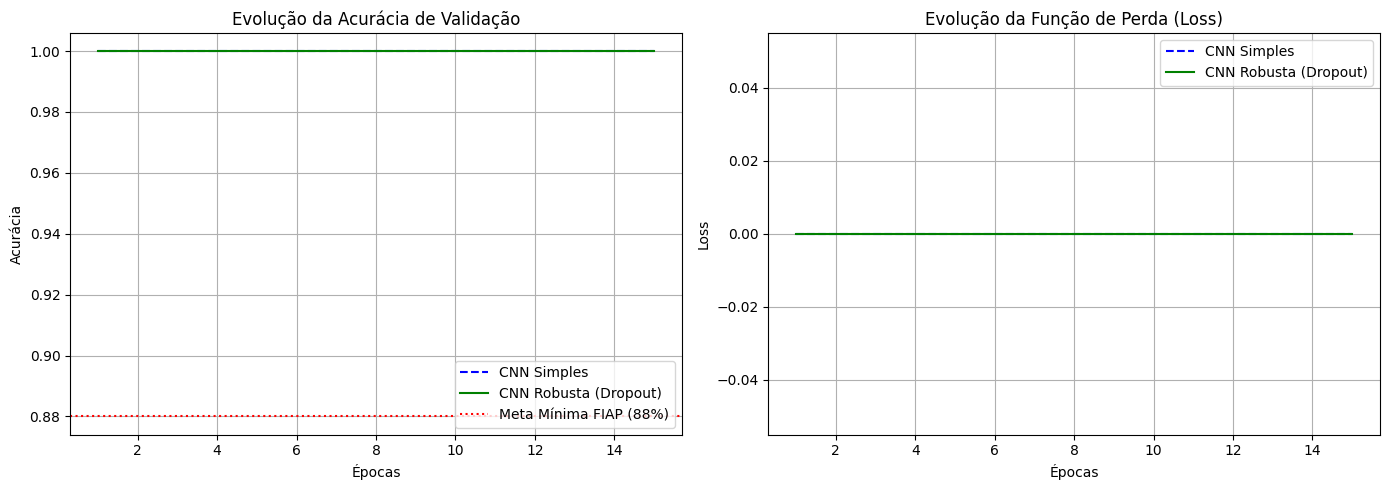

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import os

PASTA_DATASET = "dataset_satelite"
IMG_ALTURA, IMG_LARGURA = 128, 128
BATCH_SIZE = 8
EPOCHS = 15

train_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(PASTA_DATASET, "train"),
    image_size=(IMG_ALTURA, IMG_LARGURA),
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(PASTA_DATASET, "validation"),
    image_size=(IMG_ALTURA, IMG_LARGURA),
    batch_size=BATCH_SIZE
)

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

print("\n[IA] Treinando Arquitetura 1 (CNN Simples)...")
modelo_simples = models.Sequential([
    layers.Rescaling(1./255, input_shape=(IMG_ALTURA, IMG_LARGURA, 3)),
    layers.Conv2D(16, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(32, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(32, activation='relu'),
    layers.Dense(2)
])

modelo_simples.compile(optimizer='adam',
                      loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
                      metrics=['accuracy'])

historico_simples = modelo_simples.fit(train_ds, validation_data=val_ds, epochs=EPOCHS)

print("\n[IA] Treinando Arquitetura 2 (CNN Robusta com Dropout)...")
modelo_robusto = models.Sequential([
    layers.Rescaling(1./255, input_shape=(IMG_ALTURA, IMG_LARGURA, 3)),
    layers.Conv2D(32, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),
    layers.Dropout(0.3), 
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(2)
])

modelo_robusto.compile(optimizer='adam',
                      loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
                      metrics=['accuracy'])

historico_robusto = modelo_robusto.fit(train_ds, validation_data=val_ds, epochs=EPOCHS)

acc_s = historico_simples.history['val_accuracy']
acc_r = historico_robusto.history['val_accuracy']
loss_s = historico_simples.history['val_loss']
loss_r = historico_robusto.history['val_loss']
epochs_range = range(1, EPOCHS + 1)

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc_s, label='CNN Simples', color='blue', linestyle='--')
plt.plot(epochs_range, acc_r, label='CNN Robusta (Dropout)', color='green')
plt.axhline(y=0.88, color='red', linestyle=':', label='Meta Mínima FIAP (88%)')
plt.title('Evolução da Acurácia de Validação')
plt.xlabel('Épocas')
plt.ylabel('Acurácia')
plt.legend(loc='lower right')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss_s, label='CNN Simples', color='blue', linestyle='--')
plt.plot(epochs_range, loss_r, label='CNN Robusta (Dropout)', color='green')
plt.title('Evolução da Função de Perda (Loss)')
plt.xlabel('Épocas')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.grid(True)

plt.tight_layout()
plt.savefig("comparacao_modelos_cnn.png")
plt.show()

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step


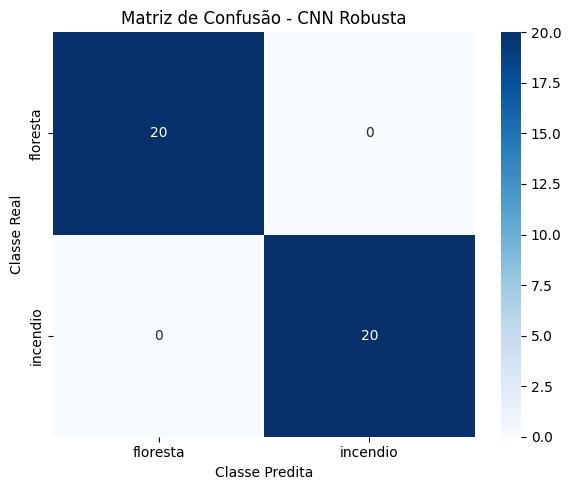

[SUCESSO] Matriz de confusão gerada e salva como 'matriz_confusao.png'!


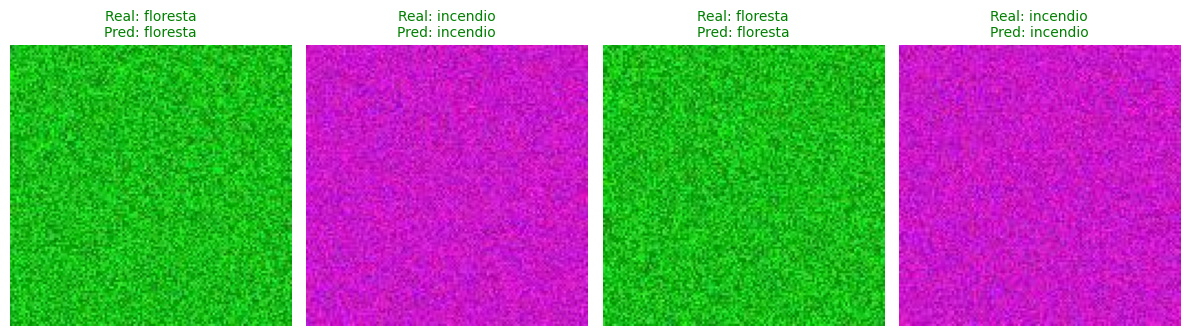

[SUCESSO] Exemplos de acertos/erros salvos como 'exemplos_predicao.png'!


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns

imagens_teste, labels_reais = [], []
for img, label in val_ds:
    imagens_teste.append(img.numpy())
    labels_reais.append(label.numpy())

imagens_teste = np.concatenate(imagens_teste, axis=0)
labels_reais = np.concatenate(labels_reais, axis=0)

predicoes_logits = modelo_robusto.predict(imagens_teste)
labels_preditos = np.argmax(predicoes_logits, axis=1)

nome_classes = ['floresta', 'incendio']

cm = confusion_matrix(labels_reais, labels_preditos)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=nome_classes, yticklabels=nome_classes)
plt.title('Matriz de Confusão - CNN Robusta')
plt.ylabel('Classe Real')
plt.xlabel('Classe Predita')
plt.tight_layout()
plt.savefig("matriz_confusao.png")
plt.show()
print("[SUCESSO] Matriz de confusão gerada e salva como 'matriz_confusao.png'!")

plt.figure(figsize=(12, 6))

for i in range(min(4, len(imagens_teste))):
    plt.subplot(1, 4, i + 1)


    img_exibir = imagens_teste[i]
    if np.max(img_exibir) > 1.0:
        img_exibir = img_exibir / 255.0
    img_exibir = np.clip(img_exibir, 0.0, 1.0)

    plt.imshow(img_exibir)

    real = nome_classes[labels_reais[i]]
    pred = nome_classes[labels_preditos[i]]

    cor = 'green' if real == pred else 'red'

    plt.title(f"Real: {real}\nPred: {pred}", color=cor, fontsize=10)
    plt.axis('off')

plt.tight_layout()
plt.savefig("exemplos_predicao.png")
plt.show()
print("[SUCESSO] Exemplos de acertos/erros salvos como 'exemplos_predicao.png'!")